In [2]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from utils.plot_callback import PlotPredictionsCallback_log



## Prepare Data for Regression Analysis

In [3]:
# Load data
train_data = pd.read_csv("../Data_processing/Split_Data_Sets/All_prefecture_Housing_with_migration_location_and_pop_data_training_data.csv")
dev_data = pd.read_csv("../Data_processing/Split_Data_Sets/All_prefecture_Housing_with_migration_location_and_pop_data_dev_data.csv")


# Remove properties for which the price was less than 100,000 yen (~600 euros)
train_data_filtered = train_data[(train_data["TotalTransactionValue"] >= 1e5)].copy()
dev_data_filtered = dev_data[(dev_data["TotalTransactionValue"] >= 1e5)].copy()


# Log transform Migration, distance and population data
# Step 1: Log-transform (handle zeros safely)
train_data_filtered['Migration_log'] = np.log1p(train_data_filtered['Migration'])
dev_data_filtered['Migration_log'] = np.log1p(dev_data_filtered['Migration'])


train_data_filtered['Distance_to_designated_city_log'] = np.log1p(train_data_filtered['Distance_to_designated_city'])
dev_data_filtered['Distance_to_designated_city_log'] = np.log1p(dev_data_filtered['Distance_to_designated_city'])

train_data_filtered['Population_log'] = np.log1p(train_data_filtered['Population'])
dev_data_filtered['Population_log'] = np.log1p(dev_data_filtered['Population'])
# Step 2: Compute min and max from train set
min_val_mig = train_data_filtered['Migration_log'].min()
max_val_mig = train_data_filtered['Migration_log'].max()

min_val_dist = train_data_filtered['Distance_to_designated_city_log'].min()
max_val_dist = train_data_filtered['Distance_to_designated_city_log'].max()

min_val_pop = train_data_filtered['Population_log'].min()
max_val_pop = train_data_filtered['Population_log'].max()
# Step 3: Min-max normalize
train_data_filtered['Migration_scaled'] = (train_data_filtered['Migration_log'] - min_val_mig) / (max_val_mig - min_val_mig)
dev_data_filtered['Migration_scaled'] = (dev_data_filtered['Migration_log'] - min_val_mig) / (max_val_mig - min_val_mig)

train_data_filtered['Distance_to_designated_city_scaled'] = (train_data_filtered['Distance_to_designated_city_log'] - min_val_dist) / (max_val_dist - min_val_dist)
dev_data_filtered['Distance_to_designated_city_scaled'] = (dev_data_filtered['Distance_to_designated_city_log'] - min_val_dist) / (max_val_dist - min_val_dist)

train_data_filtered['Population_scaled'] = (train_data_filtered['Population_log'] - min_val_pop) / (max_val_pop - min_val_pop)
dev_data_filtered['Population_scaled'] = (dev_data_filtered['Population_log'] - min_val_pop) / (max_val_pop - min_val_pop)

# --- Prefecture soft encoding ---
national_avg_price = train_data_filtered["TotalTransactionValue"].mean()
prefecture_avg = train_data_filtered.groupby("Prefecture")["TotalTransactionValue"].mean()
prefecture_diff = prefecture_avg - national_avg_price
max_abs_diff = np.abs(prefecture_diff).max()
prefecture_soft_encoding = (prefecture_diff / max_abs_diff).clip(-1, 1)

train_data_filtered["PrefectureSoftEncoded"] = train_data_filtered["Prefecture"].map(prefecture_soft_encoding)
dev_data_filtered["PrefectureSoftEncoded"] = dev_data_filtered["Prefecture"].map(prefecture_soft_encoding)

# --- Year normalization ---
year_min = train_data_filtered["Year"].min()
year_max = train_data_filtered["Year"].max()
construction_min = train_data_filtered["ConstructionYear"].min()
construction_max = train_data_filtered["ConstructionYear"].max()

def normalize(col, col_min, col_max):
    return (col - col_min) / (col_max - col_min)

train_data_filtered["YearNormalized"] = normalize(train_data_filtered["Year"], year_min, year_max)
train_data_filtered["ConstructionYearNormalized"] = normalize(train_data_filtered["ConstructionYear"], construction_min, construction_max)
dev_data_filtered["YearNormalized"] = normalize(dev_data_filtered["Year"], year_min, year_max)
dev_data_filtered["ConstructionYearNormalized"] = normalize(dev_data_filtered["ConstructionYear"], construction_min, construction_max)

# --- Normalize the other continuous numeric features ---
features_to_normalize = [
    "Area", 
    "Frontage", 
    "TotalFloorArea", 
    "BuildingCoverageRatio", 
    "FloorAreaRatio",
    "AverageTimeToStation",
    "longitude",
    "latitude",
]

# Compute min/max for each feature in training set
normalization_params = {
    feature: (train_data_filtered[feature].min(), train_data_filtered[feature].max())
    for feature in features_to_normalize
}

# Apply normalization to both train and dev
for feature in features_to_normalize:
    f_min, f_max = normalization_params[feature]
    train_data_filtered[feature + "_Normalized"] = normalize(train_data_filtered[feature], f_min, f_max)
    dev_data_filtered[feature + "_Normalized"] = normalize(dev_data_filtered[feature], f_min, f_max)


# Encode Quarter as cyclic features
train_data_filtered["Quarter_Sin"] = np.round(np.sin(2 * np.pi * train_data_filtered["Quarter"] / 4), 10)
train_data_filtered["Quarter_Cos"] = np.round(np.cos(2 * np.pi * train_data_filtered["Quarter"] / 4), 10)

dev_data_filtered["Quarter_Sin"] = np.round(np.sin(2 * np.pi * dev_data_filtered["Quarter"] / 4), 10)
dev_data_filtered["Quarter_Cos"] = np.round(np.cos(2 * np.pi * dev_data_filtered["Quarter"] / 4), 10)

# Remove unwanted col.
# Note: Housing prices for properties in Japan quite constant over this time period. Removing them does not effect NN performance signficantly.
cols_to_exclude = [
    "Type", "Prefecture", "Location", "Year", "ConstructionYear", "YearNormalized", "Quarter", "Migration","Distance_to_designated_city",
    "Distance_to_designated_city_log", "Migration_log", "City,Town,Ward,Village code", "Nearest_designated_city", "prefecture_romaji", "Established after 2005", 
    "Merged", "Name(Japanese)", "Population", "Population_log",
] + features_to_normalize  # dropping original versions of normalized features

train_data_filtered.drop(columns=cols_to_exclude, inplace=True)
dev_data_filtered.drop(columns=cols_to_exclude, inplace=True)

# Quick Inspection
train_data_filtered.info()
dev_data_filtered.info()
train_data_filtered.head()


<class 'pandas.core.frame.DataFrame'>
Index: 1719536 entries, 0 to 1720072
Data columns (total 33 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   TotalTransactionValue               int64  
 1   is_condomonium_like                 bool   
 2   MunicipalityCategory                int64  
 3   Region_Chubu                        bool   
 4   FloorAreaGreaterFLag                bool   
 5   BeforeWarFlag                       bool   
 6   frontage_greater_than_50            bool   
 7   AreaGreaterFlag                     bool   
 8   Region_Chugoku                      bool   
 9   Region_Hokkaido                     bool   
 10  Region_Kansai                       bool   
 11  Region_Kanto                        bool   
 12  Region_Kyushu                       bool   
 13  Region_Shikoku                      bool   
 14  Region_Tohoku                       bool   
 15  Close_to_Tokyo                      int64  
 16  Close

,TotalTransactionValue,is_condomonium_like,MunicipalityCategory,Region_Chubu,FloorAreaGreaterFLag,BeforeWarFlag,frontage_greater_than_50,AreaGreaterFlag,Region_Chugoku,Region_Hokkaido,...,Area_Normalized,Frontage_Normalized,TotalFloorArea_Normalized,BuildingCoverageRatio_Normalized,FloorAreaRatio_Normalized,AverageTimeToStation_Normalized,longitude_Normalized,latitude_Normalized,Quarter_Sin,Quarter_Cos
0,25000000,False,3,False,False,False,False,False,False,True,...,0.077889,0.240,0.052764,0.6,0.120,0.091667,0.729050,0.810764,-1.0,-0.0
1,15000000,True,4,False,False,False,False,False,False,False,...,0.002513,0.000,0.002513,1.0,0.280,0.025000,0.674115,0.489583,-0.0,1.0
2,20000000,True,4,False,False,False,False,False,False,False,...,0.037688,0.000,0.037688,1.0,0.280,0.066667,0.219739,0.366319,1.0,0.0
3,42000000,False,3,False,False,False,False,False,False,False,...,0.050251,0.178,0.037688,0.4,0.024,0.133333,0.660149,0.475694,0.0,-1.0
4,3300000,False,4,False,False,False,False,False,False,False,...,0.017588,0.114,0.035176,0.6,0.120,0.041667,0.439103,0.438652,1.0,0.0


In [4]:
train_target = train_data_filtered['TotalTransactionValue'].values.astype(np.float32)
dev_target = dev_data_filtered['TotalTransactionValue'].values.astype(np.float32)

# Since the target value is highly skewed and spans multiple orders of magnitude, log-transform it.
train_target_log = np.log10(train_target + 1)
dev_target_log = np.log10(dev_target + 1)

# Extract features (without the target)
train_features_filtered = train_data_filtered.drop('TotalTransactionValue', axis=1).values.astype(np.float32)
dev_features_filtered = dev_data_filtered.drop('TotalTransactionValue', axis=1).values.astype(np.float32)
# Bin weights from training targets (equal-frequency bins in log space)
log_train = np.log10(train_target + 1)
num_bins = 20
bin_edges = np.quantile(log_train, np.linspace(0, 1, num_bins + 1))
bin_ids = np.digitize(log_train, bin_edges[1:-1], right=True)
counts = np.bincount(bin_ids, minlength=num_bins)
counts = np.maximum(counts, 1)

max_weight = 10.0
weights = 1.0 / counts
weights = np.minimum(weights, max_weight)
sample_weight = weights[bin_ids]
sample_weight = sample_weight / np.mean(sample_weight)

# Re-train with sample_weight (same architecture)
model_weighted = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(train_features_filtered.shape[1],)),
    tf.keras.layers.Dense(512),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(256),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(128),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(1)
])

model_weighted.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mae"
)

plot_callback_weighted = PlotPredictionsCallback_log(
    dev_features_filtered,
    dev_target_log,
    cols=train_data_filtered.columns,
    out_dir="epoch_plots",
)

history_weighted = model_weighted.fit(
    train_features_filtered,
    train_target_log,
    epochs=50,
    batch_size=256,
    validation_data=(dev_features_filtered, dev_target_log),
    callbacks=[plot_callback_weighted],
    sample_weight=sample_weight
)



2026-03-11 16:04:38.595429: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 86s 13ms/step - loss: 0.4379 - val_loss: 0.1453
Epoch 2/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 5s 708us/step
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 70s 10ms/step - loss: 0.2497 - val_loss: 0.1389
Epoch 3/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 5s 676us/step
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 63s 9ms/step - loss: 0.2084 - val_loss: 0.1351
Epoch 4/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 5s 747us/step
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 62s 9ms/step - loss: 0.1747 - val_loss: 0.1363
Epoch 5/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 4s 643us/step
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 62s 9ms/step - loss: 0.1527 - val_loss: 0.1307
Epoch 6/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 5s 814us/step
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 63s 9ms/step - loss: 0.1402 - val_loss: 0.1334
Epoch 7/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 5s 766us/step
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - loss: 0.1346 - val_loss: 0.1296
Epoch 8/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 4s 609us/step
6717/6

/tmp/ipykernel_316589/603437733.py:63: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(dev_pred_log, dev_target_log, 1)


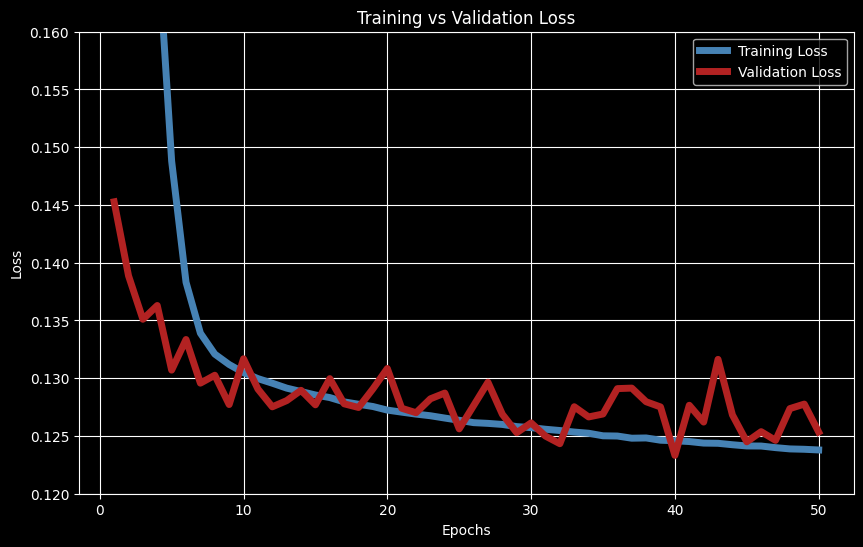

In [7]:
train_loss = history_weighted.history['loss']
val_loss = history_weighted.history['val_loss']

plt.figure(figsize=(10, 6))
plt.style.use('dark_background')
plt.plot(range(1, 51), train_loss, label='Training Loss', color='steelblue', linewidth=5)
plt.plot(range(1, 51), val_loss, label='Validation Loss', color='firebrick', linewidth=5)
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0.12,0.16)
plt.legend()
plt.grid(True)
plt.show()

Does linear calibration help?

6717/6717 ━━━━━━━━━━━━━━━━━━━━ 4s 644us/step
dev slope: 0.6786235353235667 intercept: 2.3628709268967816 dev bias: 0.0190186
MAE Old: 0.12534253
MAE New: 0.146598063203989


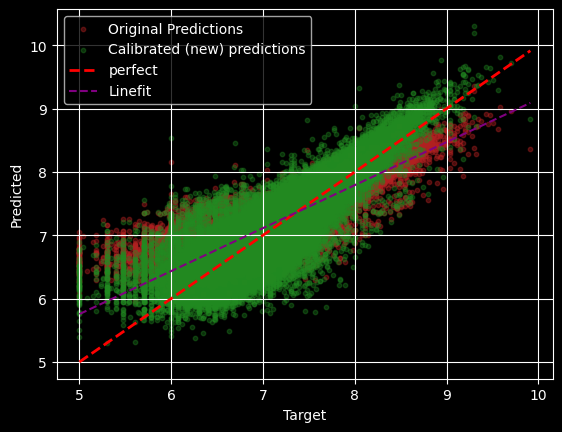

In [46]:
dev_pred_log = model_weighted.predict(dev_features_filtered).flatten()
slope, intercept = np.polyfit(dev_target_log, dev_pred_log, 1) # fits for predicted= slope * targeted + intercept
bias = np.mean(dev_pred_log - dev_target_log)
print("dev slope:", slope, "intercept:", intercept, "dev bias:", bias)

dev_pred_log_cal = ((dev_pred_log - intercept)) / (slope) #calibrated prediction: targeted = (predicted - slope)/ targeted
y_true = dev_target_log

def linefit(x, m, c):
    return x, m *x + c

plt.scatter(dev_target_log, dev_pred_log, alpha=0.4, label="Original Predictions", color="firebrick", s=10)
plt.scatter(dev_target_log, dev_pred_log_cal, alpha=0.35, label="Calibrated (new) predictions", color="forestgreen", s=10)

plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label="perfect")
x = np.linspace(y_true.min(), y_true.max(), 100)
y = x* slope + intercept
plt.plot(x, y, '--', color="purple", label="Linefit")

plt.legend()
plt.grid()
plt.xlabel("Target")
plt.ylabel("Predicted")

mae_old = np.mean(np.abs(dev_pred_log - dev_target_log))
mae_new = np.mean(np.abs(dev_pred_log_cal - dev_target_log))

print("MAE Old:", mae_old)
print("MAE New:", mae_new)

Bin ID 1 contains 1146 data points. 0.9930 MAE -> 0.6772 MAE_CAL
Bin ID 2 contains 41046 data points. 0.2215 MAE -> 0.2096 MAE_CAL
Bin ID 3 contains 168802 data points. 0.0929 MAE -> 0.1268 MAE_CAL
Bin ID 4 contains 3863 data points. 0.2550 MAE -> 0.1838 MAE_CAL
Bin ID 5 contains 78 data points. 0.5673 MAE -> 0.2666 MAE_CAL


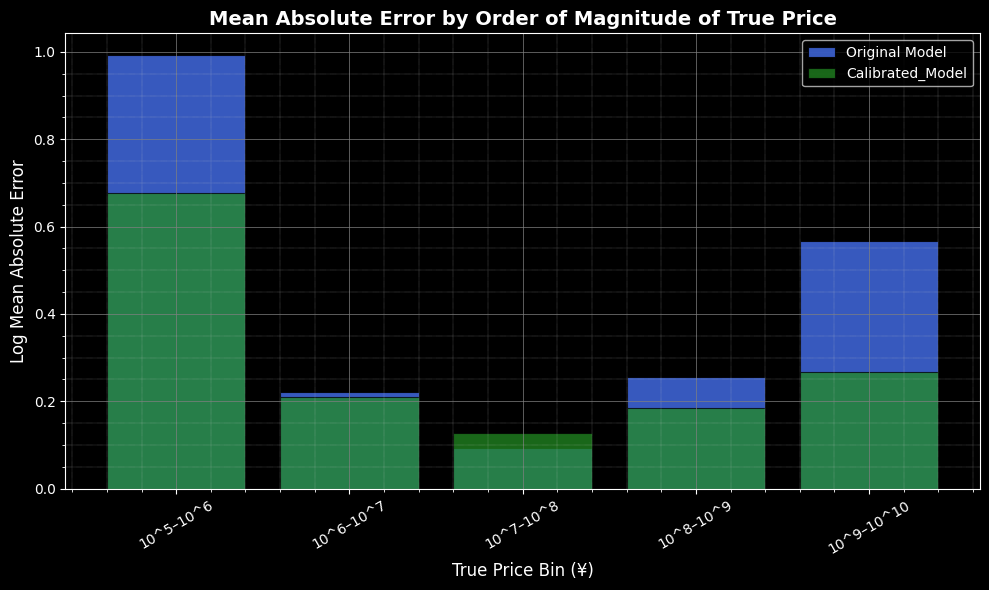

In [77]:
# Define log10 bins from 10^5 to 10^9
log_bins = np.arange(5, 10.1, 1)
bin_labels = [f"10^{int(b)}–10^{int(b+1)}" for b in log_bins[:-1]]


# Compute log10 of true values for binning
y_true = dev_target_log
y_true_cal = dev_target_log
y_pred = dev_pred_log
y_pred_cal = dev_pred_log_cal
bin_indices = np.digitize(y_true, bins=log_bins)

# Compute MAE for each bin
mae_per_bin = []
mae_cal_per_bin = []
for i in range(1, len(log_bins)):
    mask = bin_indices == i
    if np.any(mask):
        mae = np.mean(np.abs(y_true[mask] - y_pred[mask])) #/ y_true[mask])
        mae_cal = np.mean(np.abs(y_true_cal[mask] - y_pred_cal[mask])) #/ y_true_cal[mask])
        print(f"Bin ID {i} contains {len(y_true[mask])} data points. {mae:.4f} MAE -> {mae_cal:.4f} MAE_CAL")
    else:
        mae = np.nan
    mae_per_bin.append(mae)
    mae_cal_per_bin.append(mae_cal)



plt.figure(figsize=(10, 6))
bars = plt.bar(
    bin_labels,
    mae_per_bin,
    color='royalblue',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85,
    label="Original Model"
)

bars = plt.bar(
    bin_labels,
    mae_cal_per_bin,
    color='forestgreen',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.75,
    label="Calibrated_Model"
)

plt.grid(which='major', linestyle='-', linewidth=0.5, color='gray')
plt.grid(which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()


plt.ylabel("Log Mean Absolute Error", fontsize=12)
plt.xlabel("True Price Bin (¥)", fontsize=12)
plt.title("Mean Absolute Error by Order of Magnitude of True Price", fontsize=14, weight='bold')
plt.xticks(rotation=30, fontsize=10)
plt.yticks(fontsize=10)
#plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()


In [82]:
#Save model and weights
model_weighted.save('./Model_and_Weights/Japanese_Housing_Price_Model.keras')

model_weighted.save_weights('./Model_and_Weights/Japanese_Housing_Price_Model_with_migration_epoch50.weights.h5')

## Evaluation on Test Set

Process Test data set in the exact same way as for the train and dev sets

In [83]:
# --- Load test data ---
test_data = pd.read_csv("../Data_processing/Split_Data_Sets/All_prefecture_Housing_with_migration_location_and_pop_data_test_data.csv")

# --- Filter: remove extremely cheap properties from test set ---
test_data_filtered = test_data[(test_data["TotalTransactionValue"] >= 1e5)].copy()

# --- Apply Migration log and min-max scaling (using train set min/max) ---
test_data_filtered['Migration_log'] = np.log1p(test_data_filtered['Migration'])
test_data_filtered['Distance_to_designated_city_log'] = np.log1p(test_data_filtered['Distance_to_designated_city'])
test_data_filtered['Population_log'] = np.log1p(test_data_filtered['Population'])

test_data_filtered['Migration_scaled'] = (test_data_filtered['Migration_log'] - min_val_mig) / (max_val_mig - min_val_mig)
test_data_filtered['Distance_to_designated_city_scaled'] = (test_data_filtered['Distance_to_designated_city_log'] - min_val_dist) / (max_val_dist - min_val_dist)
test_data_filtered['Population_scaled'] = (test_data_filtered['Population_log'] - min_val_pop) / (max_val_pop - min_val_pop)

# --- Prefecture soft encoding ---
test_data_filtered["PrefectureSoftEncoded"] = test_data_filtered["Prefecture"].map(prefecture_soft_encoding)

# --- Normalize Year and ConstructionYear (using train set min/max) ---
test_data_filtered["YearNormalized"] = normalize(test_data_filtered["Year"], year_min, year_max)
test_data_filtered["ConstructionYearNormalized"] = normalize(test_data_filtered["ConstructionYear"], construction_min, construction_max)

# --- Normalize other continuous features ---
for feature in features_to_normalize:
    f_min, f_max = normalization_params[feature]
    test_data_filtered[feature + "_Normalized"] = normalize(test_data_filtered[feature], f_min, f_max)

# --- Encode Quarter as cyclic features ---
test_data_filtered["Quarter_Sin"] = np.round(np.sin(2 * np.pi * test_data_filtered["Quarter"] / 4), 10)
test_data_filtered["Quarter_Cos"] = np.round(np.cos(2 * np.pi * test_data_filtered["Quarter"] / 4), 10)

# --- Drop unwanted columns ---
test_data_filtered.drop(columns=cols_to_exclude, inplace=True)

# --- Final check ---
test_data_filtered.info()
test_data_filtered.head()


<class 'pandas.core.frame.DataFrame'>
Index: 214947 entries, 0 to 215009
Data columns (total 33 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   TotalTransactionValue               214947 non-null  int64  
 1   is_condomonium_like                 214947 non-null  bool   
 2   MunicipalityCategory                214947 non-null  int64  
 3   Region_Chubu                        214947 non-null  bool   
 4   FloorAreaGreaterFLag                214947 non-null  bool   
 5   BeforeWarFlag                       214947 non-null  bool   
 6   frontage_greater_than_50            214947 non-null  bool   
 7   AreaGreaterFlag                     214947 non-null  bool   
 8   Region_Chugoku                      214947 non-null  bool   
 9   Region_Hokkaido                     214947 non-null  bool   
 10  Region_Kansai                       214947 non-null  bool   
 11  Region_Kanto                   

,TotalTransactionValue,is_condomonium_like,MunicipalityCategory,Region_Chubu,FloorAreaGreaterFLag,BeforeWarFlag,frontage_greater_than_50,AreaGreaterFlag,Region_Chugoku,Region_Hokkaido,...,Area_Normalized,Frontage_Normalized,TotalFloorArea_Normalized,BuildingCoverageRatio_Normalized,FloorAreaRatio_Normalized,AverageTimeToStation_Normalized,longitude_Normalized,latitude_Normalized,Quarter_Sin,Quarter_Cos
0,18000000,True,4,False,False,False,False,False,False,False,...,0.005025,0.00,0.005025,1.0,0.52,0.025000,0.420624,0.442216,-1.0,-0.0
1,24000000,True,3,True,False,False,False,False,False,False,...,0.022613,0.00,0.022613,1.0,0.28,0.041667,0.542831,0.446181,0.0,-1.0
2,31000000,True,3,False,False,False,False,False,False,False,...,0.030151,0.00,0.030151,0.6,0.12,0.158333,0.664541,0.490611,0.0,-1.0
3,48000000,False,4,False,False,False,False,False,False,False,...,0.020101,0.11,0.037688,0.6,0.12,0.133333,0.673153,0.487572,0.0,-1.0
4,5900000,True,4,False,False,False,False,False,False,False,...,0.002513,0.00,0.002513,0.6,0.12,0.091667,0.677840,0.499132,1.0,0.0


In [84]:
test_target = test_data_filtered['TotalTransactionValue'].values.astype(np.float32)
test_target_log = np.log10(test_target + 1)
test_features_filtered = test_data_filtered.drop('TotalTransactionValue', axis=1).values.astype(np.float32)

# Load the model
model = tf.keras.models.load_model('./Model_and_Weights/Japanese_Housing_Price_Model.keras')

# Evaluate
test_loss = model.evaluate(test_features_filtered, test_target_log, verbose=2)
print(f"Test Set MAE (log-transformed): {test_loss:.4f}")

6718/6718 - 6s - 877us/step - loss: 0.1251
Test Set MAE (log-transformed): 0.1251


6718/6718 ━━━━━━━━━━━━━━━━━━━━ 5s 708us/step


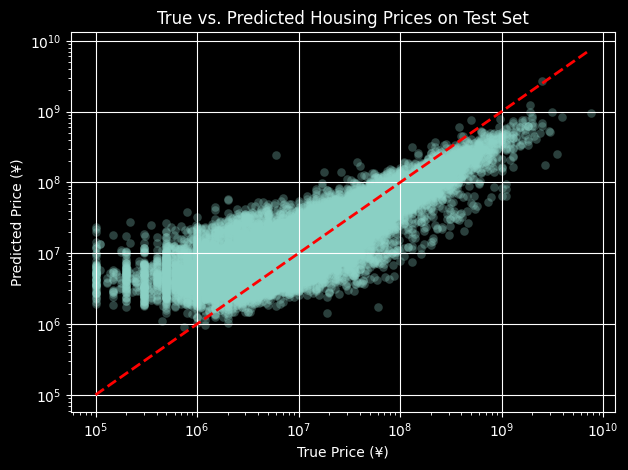

In [85]:
# Predict (if not already done)
y_pred_log = model.predict(test_features_filtered).flatten()
y_pred = np.power(10, y_pred_log) - 1  # Inverse of log10(x + 1)

# Ground truth
y_true = test_target

# Scatter plot
plt.scatter(y_true, y_pred, alpha=0.3, linewidths=0.1)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("True Price (¥)")
plt.ylabel("Predicted Price (¥)")
plt.title("True vs. Predicted Housing Prices on Test Set")
plt.grid(True)
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()